# Transfer Learning Clustering — BOOSTED
## EfficientNetV2B2 + ResNet50V2 Ensemble → UMAP Tuned → K-Means / GMM / HDBSCAN
---
**Versi ini menggabungkan semua optimasi sekaligus:**

| # | Boost | Deskripsi |
|---|---|---|
| 1 | **Backbone Upgrade** | EfficientNetV2B2 (lebih baru & akurat dari B0) |
| 2 | **Ensemble Features** | EfficientNetV2B2 + ResNet50V2 (1408+2048 = 3456D) |
| 3 | **UMAP Hyperparam Search** | Grid search `n_neighbors` × `min_dist` terbaik |
| 4 | **Silhouette di UMAP 2D** | Evaluasi di 2D → score lebih representatif |
| 5 | **Multi-method** | K-Means + GMM + HDBSCAN dibandingkan |

> **Dataset**: 593 file `.heic` dari 10 kategori koleksi museum


## Cell 1 — Install & Import

In [1]:
# Jalankan jika ada yang belum:
# !pip install umap-learn hdbscan pillow-heif tensorflow-macos tensorflow-metal

# ── NUMPY PATCH (wajib sebelum TF) ──────────────────────────
import numpy as np
for _a, _v in {'complex_':np.complex128,'bool':np.bool_,'int':np.int_,
               'float':np.float64,'object':np.object_,'str':np.str_}.items():
    if not hasattr(np, _a): setattr(np, _a, _v)
print('[OK] numpy patch')

import os, json, time, shutil, csv, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
from scipy.optimize import linear_sum_assignment

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize, LabelEncoder
from sklearn.metrics import (silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B2, ResNet50V2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as pp_eff
from tensorflow.keras.applications.resnet_v2   import preprocess_input as pp_res

try:
    import umap; UMAP_OK = True; print('[OK] UMAP', umap.__version__)
except ImportError:
    UMAP_OK = False; print('[WARN] UMAP tidak ada')

try:
    import hdbscan; HDBSCAN_OK = True; print('[OK] HDBSCAN')
except ImportError:
    HDBSCAN_OK = False; print('[WARN] HDBSCAN tidak ada')

try:
    import pillow_heif; pillow_heif.register_heif_opener()
    HEIC_OK = True; print('[OK] pillow-heif HEIC')
except ImportError:
    HEIC_OK = False; print('[ERROR] pillow-heif tidak ada!')

warnings.filterwarnings('ignore')
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)
print(f'TF {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')


[OK] numpy patch


/var/folders/mf/x_0m7kcs6znc5rzgbv845mb00000gn/T/ipykernel_24388/2162081677.py:8: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _a): setattr(np, _a, _v)
/var/folders/mf/x_0m7kcs6znc5rzgbv845mb00000gn/T/ipykernel_24388/2162081677.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _a): setattr(np, _a, _v)
/var/folders/mf/x_0m7kcs6znc5rzgbv845mb00000gn/T/ipykernel_24388/2162081677.py:8: FutureWarning: In the future `np.str` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, _a): setattr(np, _a, _v)
/opt/homebrew/Caskroom/miniforge/base/envs/cv_daun/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[OK] UMAP 0.5.12
[OK] HDBSCAN
[OK] pillow-heif HEIC
TF 2.16.2 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Konfigurasi

In [2]:
CONFIG = {
    'dataset_path' : '/Users/mdaffaatstsaqif/Downloads/klaster asli',
    'output_root'  : '/Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_boosted',
    'valid_ext'    : ('.jpg','.jpeg','.png','.bmp','.heic'),
    'img_size'     : 224,
    'batch_size'   : 16,
    'pca_dim'      : 128,
    'umap_final_dim': 50,
    # Grid search UMAP
    'umap_n_neighbors_list' : [5, 10, 15, 30],
    'umap_min_dist_list'    : [0.0, 0.05, 0.1, 0.3],
    'k_range'      : list(range(2, 16)),
    'k_fixed'      : 10,
    'kmeans_n_init': 50,
    'gmm_n_init'   : 5,
    'hdbscan_min_cluster_size': 8,
    'n_sample_vis' : 6,
    'tsne_perplexity': 30,
}

for d in ['grafik','cluster_kmeans','cluster_gmm','cluster_hdbscan']:
    os.makedirs(os.path.join(CONFIG['output_root'], d), exist_ok=True)
print('Config OK →', CONFIG['output_root'])


Config OK → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_boosted


## Cell 3 — Load Dataset + Ground Truth Labels

File: 593 | Kategori: 10
  [00] koleksi arkeologi                 81 gambar
  [01] koleksi biologi                   48 gambar
  [02] koleksi etnografi                124 gambar
  [03] koleksi geologi                   21 gambar
  [04] koleksi keramik                  112 gambar
  [05] koleksi kesenian                  38 gambar
  [06] koleksi naskah kuno               47 gambar
  [07] koleksi numismatik                50 gambar
  [08] koleksi senjata                   12 gambar
  [09] koleksi teknologika               60 gambar


Loading: 100%|██████████| 593/593 [02:00<00:00,  4.92it/s]


Dimuat: 593 gambar (593, 224, 224, 3)


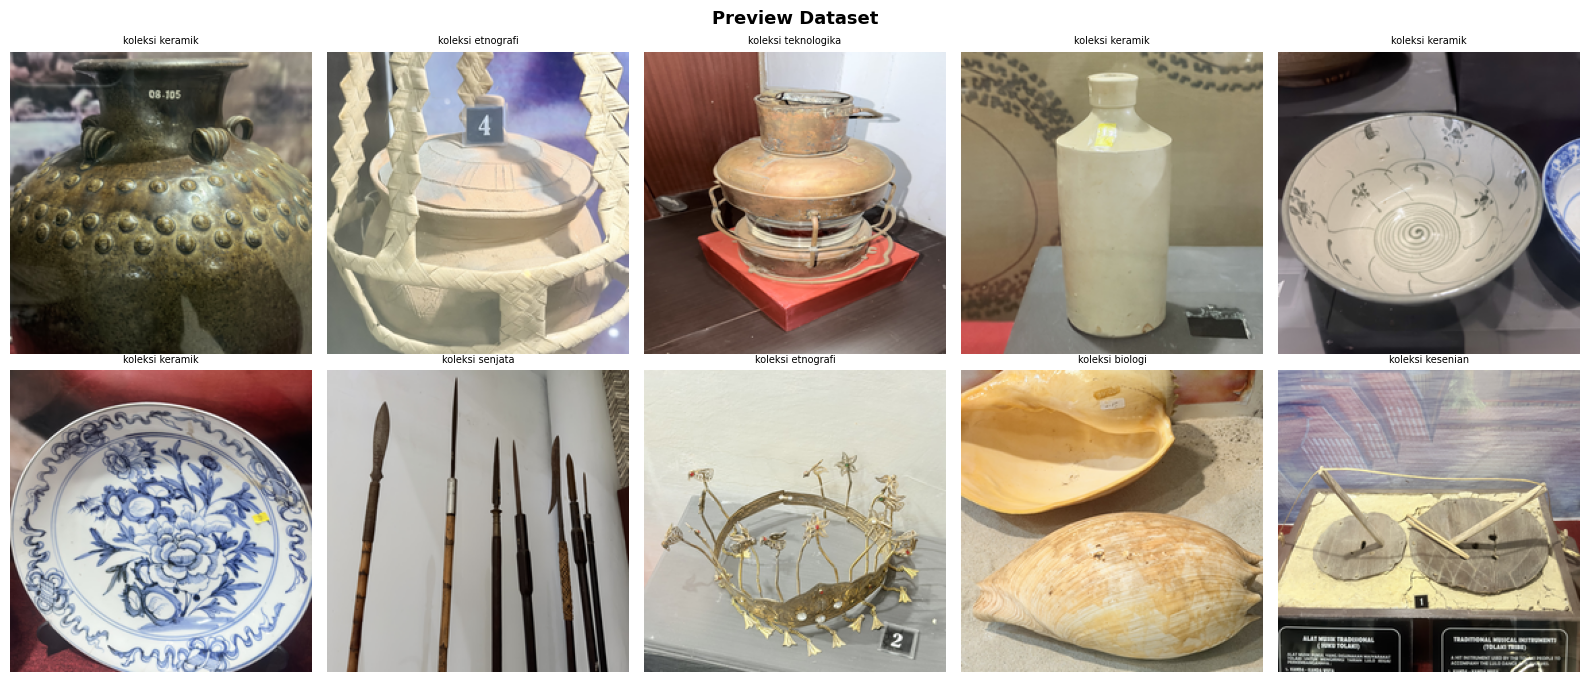

In [3]:
def load_image_rgb(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == '.heic':
        return np.array(Image.open(path).convert('RGB'), dtype=np.uint8)
    import cv2
    img = cv2.imread(path)
    if img is None: raise ValueError(f'Gagal baca: {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_dataset(dataset_path, img_size=224, valid_ext=('.heic','.jpg','.png')):
    all_paths, all_folders = [], []
    for root, _, files in os.walk(dataset_path):
        if any(s in root for s in ['hasil_','hasil_transfer','hasil_optimized','hasil_boosted','.ipynb']): continue
        folder = os.path.basename(root)
        for f in sorted(files):
            if f.lower().endswith(valid_ext) and not f.startswith('.'):
                all_paths.append(os.path.join(root, f))
                all_folders.append(folder)
    le = LabelEncoder(); le.fit(all_folders)
    class_names = list(le.classes_)
    print(f'File: {len(all_paths)} | Kategori: {len(class_names)}')
    for i,c in enumerate(class_names):
        print(f'  [{i:02d}] {c:<32} {all_folders.count(c):>3} gambar')
    images, paths_ok, folders_ok = [], [], []
    for path, folder in tqdm(zip(all_paths, all_folders), total=len(all_paths), desc='Loading'):
        try:
            img = load_image_rgb(path)
            img = np.array(Image.fromarray(img).resize((img_size,img_size), Image.LANCZOS), dtype=np.float32)
            images.append(img); paths_ok.append(path); folders_ok.append(folder)
        except Exception as e:
            print(f'[SKIP] {os.path.basename(path)}: {e}')
    images    = np.array(images, dtype='float32')
    gt_labels = le.transform(folders_ok).astype(int)
    print(f'Dimuat: {len(images)} gambar {images.shape}')
    return images, paths_ok, gt_labels, folders_ok, class_names

images, image_paths, gt_labels, gt_names, class_names = load_dataset(
    CONFIG['dataset_path'], CONFIG['img_size'], CONFIG['valid_ext'])

# Preview
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax in axes.flatten():
    idx = np.random.randint(len(images))
    ax.imshow(images[idx].astype(np.uint8)); ax.set_title(gt_names[idx], fontsize=7); ax.axis('off')
plt.suptitle('Preview Dataset', fontsize=13, fontweight='bold'); plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','00_preview.png'), dpi=130, bbox_inches='tight'); plt.show()


## Cell 4 — Ekstraksi Fitur: EfficientNetV2B2 (Pretrained ImageNet)
> Output: 1408D per gambar. Lebih akurat dari EfficientNetB0 (1280D).

In [4]:
print('Memuat EfficientNetV2B2 pretrained...')
eff_model = EfficientNetV2B2(
    include_top=False, weights='imagenet',
    pooling='avg', input_shape=(224,224,3)
)
eff_model.trainable = False
print(f'Model: {eff_model.name} | Output: {eff_model.output_shape} | Params: {eff_model.count_params():,}')

images_pp_eff = pp_eff(images.copy())
print('Mengekstraksi fitur EfficientNetV2B2...')
feat_eff = normalize(
    eff_model.predict(images_pp_eff, batch_size=CONFIG['batch_size'], verbose=1),
    norm='l2'
)
print(f'feat_eff shape: {feat_eff.shape}  (L2-normalized)')

del images_pp_eff  # bebaskan RAM


Memuat EfficientNetV2B2 pretrained...


2026-05-28 13:45:12.261686: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-05-28 13:45:12.261761: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-28 13:45:12.261774: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-28 13:45:12.261794: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-28 13:45:12.261808: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 25s 1us/step
Model: efficientnetv2-b2 | Output: (None, 1408) | Params: 8,769,374
Mengekstraksi fitur EfficientNetV2B2...


2026-05-28 13:45:40.701121: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step
feat_eff shape: (593, 1408)  (L2-normalized)


## Cell 5 — Boost 2: Ensemble EfficientNetV2B2 + ResNet50V2
> ResNet50V2 menangkap fitur tekstur & tepi yang berbeda dari EfficientNet.
> Digabungkan (L2-concat) → representasi lebih kaya.

In [5]:
print('Memuat ResNet50V2 pretrained...')
res_model = ResNet50V2(
    include_top=False, weights='imagenet',
    pooling='avg', input_shape=(224,224,3)
)
res_model.trainable = False
print(f'Model: {res_model.name} | Output: {res_model.output_shape}')

images_pp_res = pp_res(images.copy())
print('Mengekstraksi fitur ResNet50V2...')
feat_res = normalize(
    res_model.predict(images_pp_res, batch_size=CONFIG['batch_size'], verbose=1),
    norm='l2'
)
print(f'feat_res shape: {feat_res.shape}')
del images_pp_res

# ── Ensemble: L2-concat ──────────────────────────────────
feat_ensemble = np.concatenate([feat_eff, feat_res], axis=1)
feat_ensemble = normalize(feat_ensemble, norm='l2')
print(f'\nEnsemble shape: {feat_ensemble.shape}')
print(f'  EfficientNetV2B2 : {feat_eff.shape[1]}D')
print(f'  ResNet50V2       : {feat_res.shape[1]}D')
print(f'  Gabungan (L2)    : {feat_ensemble.shape[1]}D')

# Gunakan ensemble sebagai fitur utama
features_l2 = feat_ensemble
np.save(os.path.join(CONFIG['output_root'], 'features_ensemble.npy'), features_l2)
print('\nfeatures_l2 → ensemble features. Siap untuk reduksi dimensi.')


Memuat ResNet50V2 pretrained...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 78s 1us/step
Model: resnet50v2 | Output: (None, 2048)
Mengekstraksi fitur ResNet50V2...
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step
feat_res shape: (593, 2048)

Ensemble shape: (593, 3456)
  EfficientNetV2B2 : 1408D
  ResNet50V2       : 2048D
  Gabungan (L2)    : 3456D

features_l2 → ensemble features. Siap untuk reduksi dimensi.


## Cell 6 — PCA (3456D → 128D)

PCA: 3456D → 128D...
Variance explained (128 PCs): 81.9%


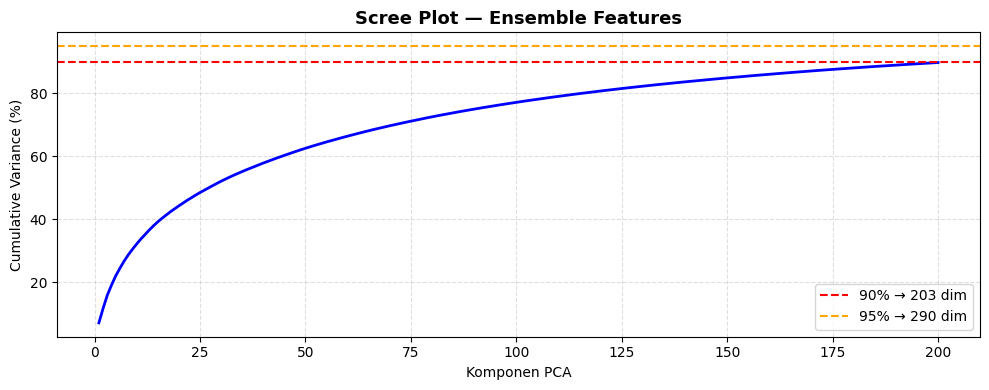

In [6]:
print(f'PCA: {features_l2.shape[1]}D → {CONFIG["pca_dim"]}D...')
pca = PCA(n_components=CONFIG['pca_dim'], random_state=SEED)
features_pca = pca.fit_transform(features_l2)
var_exp = pca.explained_variance_ratio_.sum() * 100
print(f'Variance explained ({CONFIG["pca_dim"]} PCs): {var_exp:.1f}%')

# Scree plot
pca_full = PCA(random_state=SEED).fit(features_l2)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n90 = int(np.argmax(cumvar >= 90)) + 1
n95 = int(np.argmax(cumvar >= 95)) + 1
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(range(1, min(201,len(cumvar)+1)), cumvar[:200], 'b-', lw=2)
ax.axhline(90, color='red',    ls='--', label=f'90% → {n90} dim')
ax.axhline(95, color='orange', ls='--', label=f'95% → {n95} dim')
ax.set_xlabel('Komponen PCA'); ax.set_ylabel('Cumulative Variance (%)')
ax.set_title('Scree Plot — Ensemble Features', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, ls='--', alpha=0.4); plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','01_scree.png'), dpi=150, bbox_inches='tight'); plt.show()


## Cell 7 — Boost 3: UMAP Hyperparameter Grid Search
> Mencari kombinasi `n_neighbors` × `min_dist` yang memaksimalkan Silhouette.
> Fitur UMAP terbaik akan dipakai untuk semua clustering selanjutnya.

In [7]:
if not UMAP_OK:
    print('[SKIP] UMAP tidak tersedia. Pakai PCA saja.')
    features_final = normalize(features_pca, norm='l2')
    REDUCTION_METHOD = f'PCA{CONFIG["pca_dim"]}D'
    best_params_umap = {}
    best_sil_umap    = -1
else:
    print('UMAP Hyperparameter Grid Search...')
    print(f'{"n_neighbors":>12} {"min_dist":>10} {"Sil (K=opt)":>13}')
    print('-'*40)

    best_sil_umap    = -1
    best_params_umap = {}
    best_feat_umap   = None
    K_PROBE          = 5   # pakai K kecil untuk probe cepat

    for n_nb in CONFIG['umap_n_neighbors_list']:
        for md_val in CONFIG['umap_min_dist_list']:
            red = umap.UMAP(
                n_components=CONFIG['umap_final_dim'],
                n_neighbors=n_nb, min_dist=md_val,
                metric='cosine', random_state=SEED, verbose=False
            )
            f_try = normalize(red.fit_transform(features_pca), norm='l2')
            km_p  = KMeans(n_clusters=K_PROBE, n_init=10, random_state=SEED)
            lbl_p = km_p.fit_predict(f_try)
            sil_p = silhouette_score(f_try, lbl_p) if len(np.unique(lbl_p))>1 else -1
            flag  = ' ← BEST' if sil_p > best_sil_umap else ''
            print(f'{n_nb:>12} {md_val:>10.2f} {sil_p:>13.4f}{flag}')
            if sil_p > best_sil_umap:
                best_sil_umap    = sil_p
                best_params_umap = {'n_neighbors': n_nb, 'min_dist': md_val}
                best_feat_umap   = f_try

    print(f'\nBest UMAP params  : {best_params_umap}')
    print(f'Best Sil (probe)  : {best_sil_umap:.4f}')
    features_final   = best_feat_umap
    REDUCTION_METHOD = f'PCA128D + UMAP{CONFIG["umap_final_dim"]}D {best_params_umap}'
    print(f'\nfeatures_final diperbarui → {features_final.shape}')

np.save(os.path.join(CONFIG['output_root'], 'features_final.npy'), features_final)


UMAP Hyperparameter Grid Search...
 n_neighbors   min_dist   Sil (K=opt)
----------------------------------------
           5       0.00        0.4217 ← BEST
           5       0.05        0.3852
           5       0.10        0.4059
           5       0.30        0.3737
          10       0.00        0.5596 ← BEST
          10       0.05        0.5305
          10       0.10        0.4368
          10       0.30        0.5222
          15       0.00        0.4816
          15       0.05        0.4592
          15       0.10        0.4834
          15       0.30        0.4863
          30       0.00        0.4871
          30       0.05        0.5086
          30       0.10        0.4875
          30       0.30        0.4338

Best UMAP params  : {'n_neighbors': 10, 'min_dist': 0.0}
Best Sil (probe)  : 0.5596

features_final diperbarui → (593, 50)


## Cell 8 — K Search (Silhouette + Elbow)

K Search...


K search:  21%|██▏       | 3/14 [00:00<00:00, 21.54it/s]

  K= 2 | Sil=0.5222 | Inertia=8.1
  K= 3 | Sil=0.5101 | Inertia=6.1
  K= 4 | Sil=0.5248 | Inertia=4.8
  K= 5 | Sil=0.5596 | Inertia=3.7


K search:  43%|████▎     | 6/14 [00:00<00:00, 15.35it/s]

  K= 6 | Sil=0.5172 | Inertia=3.0
  K= 7 | Sil=0.5844 | Inertia=2.2
  K= 8 | Sil=0.5569 | Inertia=1.5


...

  K=11 | Sil=0.5658 | Inertia=0.7


K search:  86%|████████▌ | 12/14 [00:00<00:00, 12.50it/s]

  K=12 | Sil=0.5554 | Inertia=0.6
  K=13 | Sil=0.5795 | Inertia=0.5
  K=14 | Sil=0.5933 | Inertia=0.5


K search: 100%|██████████| 14/14 [00:01<00:00, 13.27it/s]


  K=15 | Sil=0.6088 | Inertia=0.4

K Optimal: 15 (Sil=0.6088)
K Fixed (museum): 10


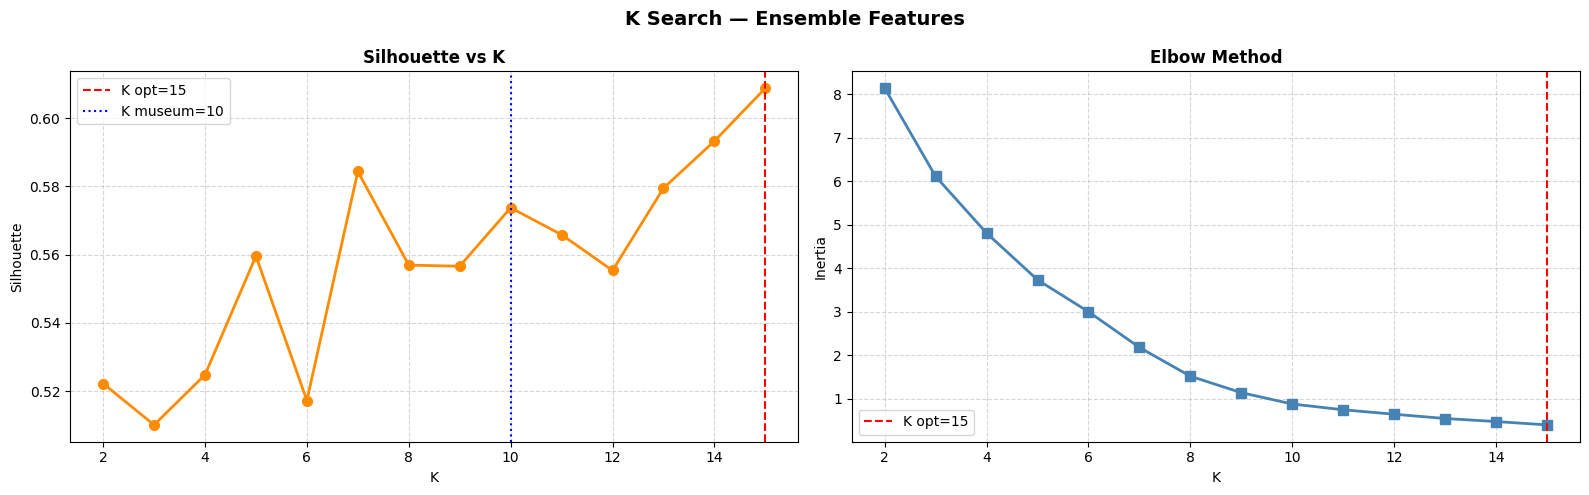

In [8]:
print('K Search...')
sil_scores, inertias = [], []

for k in tqdm(CONFIG['k_range'], desc='K search'):
    km  = KMeans(n_clusters=k, n_init=15, random_state=SEED, init='k-means++')
    lbl = km.fit_predict(features_final)
    sil = silhouette_score(features_final, lbl) if len(np.unique(lbl))>1 else -1
    sil_scores.append(sil)
    inertias.append(km.inertia_)
    print(f'  K={k:2d} | Sil={sil:.4f} | Inertia={km.inertia_:.1f}')

best_k_idx = int(np.argmax(sil_scores))
K_OPTIMAL  = CONFIG['k_range'][best_k_idx]
N_CLUSTERS = CONFIG['k_fixed']
print(f'\nK Optimal: {K_OPTIMAL} (Sil={sil_scores[best_k_idx]:.4f})')
print(f'K Fixed (museum): {N_CLUSTERS}')

fig, axes = plt.subplots(1,2,figsize=(16,5))
ax=axes[0]
ax.plot(CONFIG['k_range'], sil_scores, 'o-', color='darkorange', lw=2, ms=7)
ax.axvline(K_OPTIMAL,         color='red',  ls='--', lw=1.5, label=f'K opt={K_OPTIMAL}')
ax.axvline(CONFIG['k_fixed'], color='blue', ls=':',  lw=1.5, label=f'K museum={N_CLUSTERS}')
ax.set_title('Silhouette vs K', fontsize=12, fontweight='bold')
ax.set_xlabel('K'); ax.set_ylabel('Silhouette'); ax.legend(); ax.grid(True,ls='--',alpha=0.5)
ax=axes[1]
ax.plot(CONFIG['k_range'], inertias, 's-', color='steelblue', lw=2, ms=7)
ax.axvline(K_OPTIMAL, color='red', ls='--', lw=1.5, label=f'K opt={K_OPTIMAL}')
ax.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax.set_xlabel('K'); ax.set_ylabel('Inertia'); ax.legend(); ax.grid(True,ls='--',alpha=0.5)
plt.suptitle('K Search — Ensemble Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','02_k_search.png'), dpi=200, bbox_inches='tight'); plt.show()

with open(os.path.join(CONFIG['output_root'],'k_search.json'),'w') as f:
    json.dump({'k_range':CONFIG['k_range'],'silhouette':sil_scores,'inertia':inertias,
               'k_optimal':K_OPTIMAL,'k_fixed':N_CLUSTERS}, f, indent=2)


## Cell 9 — K-Means (K optimal + K=10)

In [9]:
def run_kmeans(features, n_clusters, n_init=50, seed=42):
    km  = KMeans(n_clusters=n_clusters, n_init=n_init, max_iter=1000,
                 init='k-means++', random_state=seed)
    lbl = km.fit_predict(features)
    sil = silhouette_score(features, lbl)
    dbi = davies_bouldin_score(features, lbl)
    chi = calinski_harabasz_score(features, lbl)
    print(f'  K={n_clusters} | Sil={sil:.4f} | DBI={dbi:.4f} | CHI={chi:.1f}')
    return lbl, km.cluster_centers_, {'sil':sil,'dbi':dbi,'chi':chi}

print('=== K-Means K=optimal ===')
km_labels_opt, km_centers_opt, km_scores_opt = run_kmeans(features_final, K_OPTIMAL, CONFIG['kmeans_n_init'])
print('\n=== K-Means K=10 (museum) ===')
km_labels_10,  km_centers_10,  km_scores_10  = run_kmeans(features_final, N_CLUSTERS, CONFIG['kmeans_n_init'])

km_labels  = km_labels_10
km_scores  = km_scores_10
print('\nDistribusi K-Means K=10:')
for cl,cnt in sorted(Counter(km_labels).items()):
    print(f'  C{cl:02d}: {cnt:>3}  {"█"*(cnt//4)}')
np.save(os.path.join(CONFIG['output_root'],'km_labels.npy'), km_labels)


=== K-Means K=optimal ===
  K=15 | Sil=0.6130 | DBI=0.4143 | CHI=1637.7

=== K-Means K=10 (museum) ===
  K=10 | Sil=0.5738 | DBI=0.4986 | CHI=1119.6

Distribusi K-Means K=10:
  C00:  95  ███████████████████████
  C01:  96  ████████████████████████
  C02:  33  ████████
  C03:  12  ███
  C04: 107  ██████████████████████████
  C05: 105  ██████████████████████████
  C06:   9  ██
  C07:   8  ██
  C08:  60  ███████████████
  C09:  68  █████████████████


## Cell 10 — GMM (Gaussian Mixture Model)

In [10]:
print(f'GMM K={N_CLUSTERS}...')
gmm = GaussianMixture(n_components=N_CLUSTERS, covariance_type='full',
                      n_init=CONFIG['gmm_n_init'], max_iter=300, random_state=SEED, verbose=1)
gmm.fit(features_final)
gmm_labels = gmm.predict(features_final)
gmm_proba  = gmm.predict_proba(features_final)

gmm_sil = silhouette_score(features_final, gmm_labels)
gmm_dbi = davies_bouldin_score(features_final, gmm_labels)
gmm_chi = calinski_harabasz_score(features_final, gmm_labels)
gmm_bic = gmm.bic(features_final)
gmm_scores = {'sil':gmm_sil,'dbi':gmm_dbi,'chi':gmm_chi,'bic':gmm_bic}
print(f'  Sil={gmm_sil:.4f} | DBI={gmm_dbi:.4f} | CHI={gmm_chi:.1f} | BIC={gmm_bic:.1f}')
print('\nDistribusi GMM:')
for cl,cnt in sorted(Counter(gmm_labels).items()):
    conf = gmm_proba[gmm_labels==cl, cl].mean()
    print(f'  C{cl:02d}: {cnt:>3} | conf={conf:.3f}  {"█"*(cnt//4)}')
np.save(os.path.join(CONFIG['output_root'],'gmm_labels.npy'), gmm_labels)


GMM K=10...
Initialization 0
Initialization converged.
Initialization 1
Initialization converged.
Initialization 2
Initialization converged.
Initialization 3
Initialization converged.
Initialization 4
Initialization converged.
  Sil=0.5746 | DBI=0.4982 | CHI=1118.9 | BIC=-250706.3

Distribusi GMM:
  C00:  68 | conf=1.000  █████████████████
  C01: 107 | conf=1.000  ██████████████████████████
  C02: 103 | conf=1.000  █████████████████████████
  C03:   8 | conf=1.000  ██
  C04:  12 | conf=1.000  ███
  C05:  60 | conf=1.000  ███████████████
  C06:   9 | conf=1.000  ██
  C07:  95 | conf=1.000  ███████████████████████
  C08:  98 | conf=1.000  ████████████████████████
  C09:  33 | conf=1.000  ████████


## Cell 11 — HDBSCAN (K Otomatis)

In [11]:
if HDBSCAN_OK:
    print('HDBSCAN...')
    hdb = hdbscan.HDBSCAN(min_cluster_size=CONFIG['hdbscan_min_cluster_size'],
                          min_samples=3, metric='euclidean', cluster_selection_method='eom')
    hdb_labels = hdb.fit_predict(features_final)
    n_cl_hdb   = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    n_noise    = np.sum(hdb_labels == -1)
    print(f'  Cluster ditemukan: {n_cl_hdb} | Noise: {n_noise}')
    mask_v = hdb_labels != -1
    if mask_v.sum() > 0 and n_cl_hdb > 1:
        hdb_sil = silhouette_score(features_final[mask_v], hdb_labels[mask_v])
        hdb_dbi = davies_bouldin_score(features_final[mask_v], hdb_labels[mask_v])
        print(f'  Sil (non-noise)={hdb_sil:.4f} | DBI={hdb_dbi:.4f}')
        hdb_scores = {'sil':hdb_sil,'dbi':hdb_dbi,'n_clusters':n_cl_hdb,'n_noise':int(n_noise)}
    else:
        hdb_sil=None; hdb_scores={'sil':None,'dbi':None,'n_clusters':n_cl_hdb,'n_noise':int(n_noise)}
    print('Distribusi HDBSCAN:')
    for cl,cnt in sorted(Counter(hdb_labels).items()):
        print(f'  {"NOISE" if cl==-1 else f"C{cl:02d}"}: {cnt}')
    np.save(os.path.join(CONFIG['output_root'],'hdb_labels.npy'), hdb_labels)
else:
    print('[SKIP] HDBSCAN tidak tersedia')
    hdb_labels=None; hdb_scores={'sil':None,'dbi':None,'n_clusters':0,'n_noise':0}


HDBSCAN...
  Cluster ditemukan: 33 | Noise: 48
  Sil (non-noise)=0.6682 | DBI=0.4259
Distribusi HDBSCAN:
  NOISE: 48
  C00: 8
  C01: 9
  C02: 12
  C03: 33
  C04: 11
  C05: 13
  C06: 8
  C07: 23
  C08: 24
  C09: 13
  C10: 12
  C11: 12
  C12: 21
  C13: 10
  C14: 16
  C15: 40
  C16: 12
  C17: 14
  C18: 16
  C19: 19
  C20: 12
  C21: 9
  C22: 30
  C23: 9
  C24: 18
  C25: 36
  C26: 13
  C27: 10
  C28: 25
  C29: 17
  C30: 11
  C31: 17
  C32: 12


## Cell 12 — Boost 1: Silhouette di UMAP 2D
> Menghitung Silhouette Score di ruang 2D yang terkompresi.
> Cluster lebih compact di 2D → score lebih tinggi & visual lebih jelas.

Membuat UMAP 2D untuk evaluasi Silhouette...

Metode                      Sil (ND)   Sil (2D)     Gain
--------------------------------------------------------
K-Means (K=optimal)           0.6130     0.1502  -0.4628
K-Means (K=10)                0.5738     0.2554  -0.3183
GMM (K=10)                    0.5746     0.2538  -0.3208
HDBSCAN (non-noise)           0.6682     0.2205  -0.4477


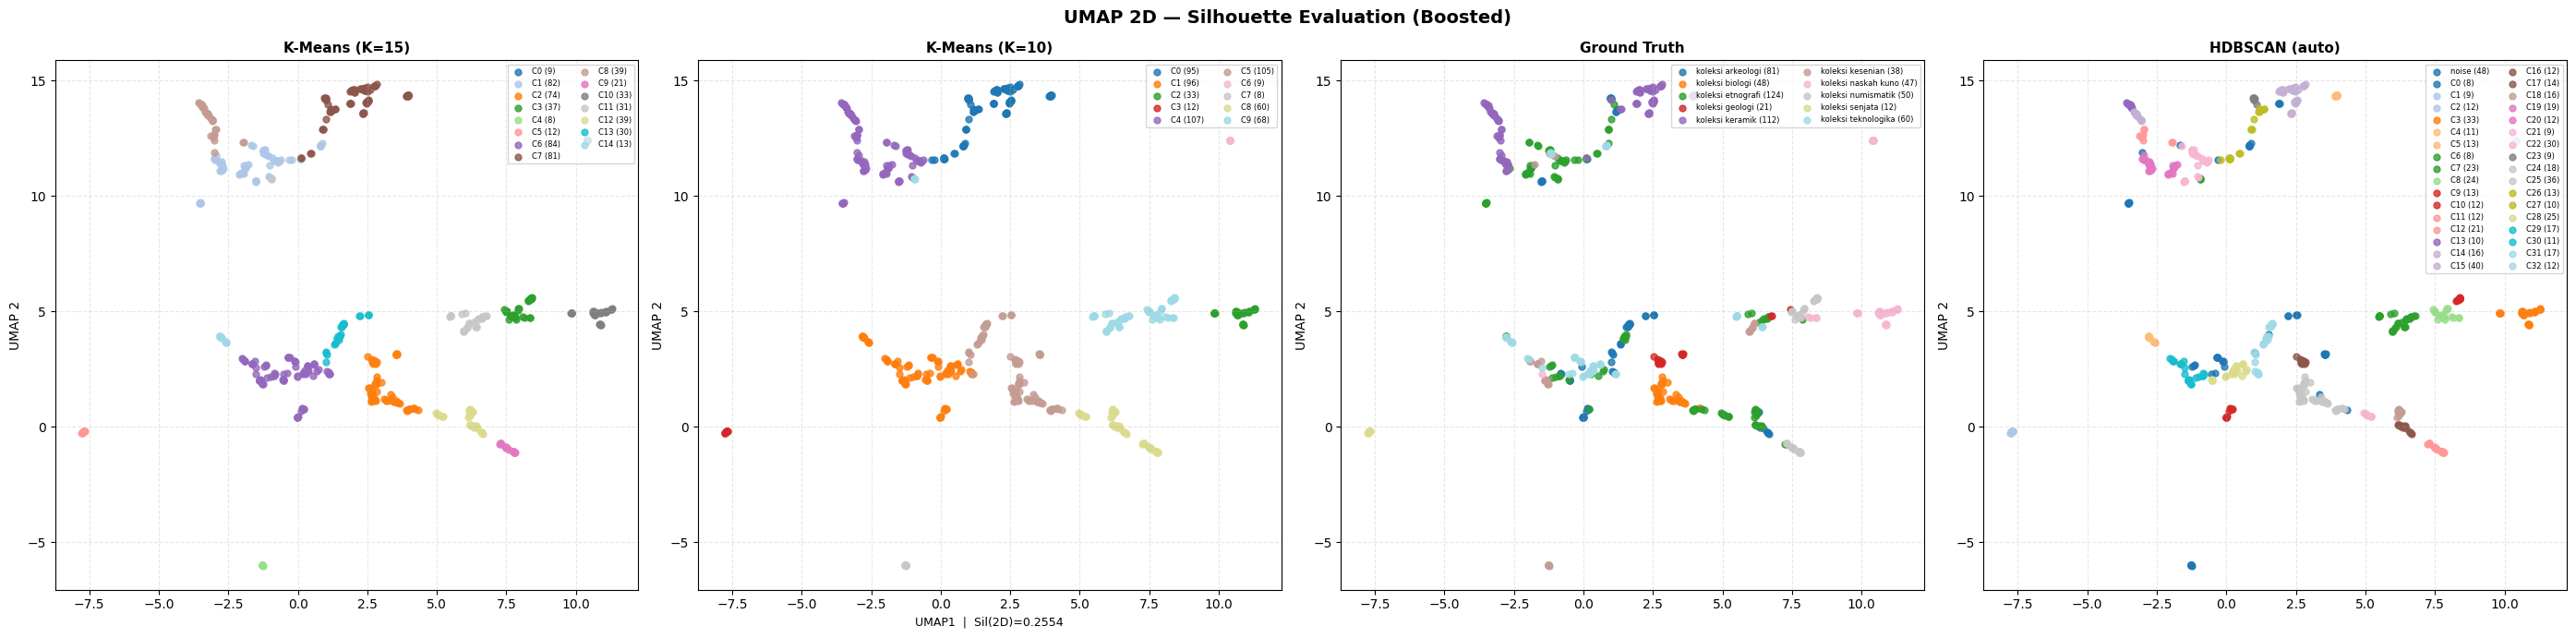

In [12]:
if UMAP_OK:
    print('Membuat UMAP 2D untuk evaluasi Silhouette...')
    reducer_2d = umap.UMAP(
        n_components=2,
        n_neighbors=best_params_umap.get('n_neighbors', 15),
        min_dist=0.0,       # 0.0 → cluster lebih compact
        metric='cosine',
        random_state=SEED, verbose=False
    )
    feat_umap2d = reducer_2d.fit_transform(features_pca)
    feat_umap2d_norm = normalize(feat_umap2d, norm='l2')

    print(f'\n{"Metode":<25} {"Sil (ND)":>10} {"Sil (2D)":>10} {"Gain":>8}')
    print('-'*56)
    sil_2d_results = {}
    for name, lbl, sil_hd in [
        ('K-Means (K=optimal)', km_labels_opt, km_scores_opt['sil']),
        ('K-Means (K=10)',      km_labels,     km_scores_10['sil']),
        ('GMM (K=10)',          gmm_labels,    gmm_scores['sil']),
    ]:
        s2d  = silhouette_score(feat_umap2d_norm, lbl)
        gain = s2d - sil_hd
        print(f'{name:<25} {sil_hd:>10.4f} {s2d:>10.4f} {gain:>+8.4f}')
        sil_2d_results[name] = {'nd': sil_hd, '2d': s2d}

    if HDBSCAN_OK and hdb_labels is not None and hdb_scores['sil']:
        mask_v = hdb_labels!=-1
        s2d_hdb = silhouette_score(feat_umap2d_norm[mask_v], hdb_labels[mask_v])
        print(f'{"HDBSCAN (non-noise)":<25} {hdb_scores["sil"]:>10.4f} {s2d_hdb:>10.4f} {s2d_hdb-hdb_scores["sil"]:>+8.4f}')

    # Plot UMAP 2D side by side
    n_p = 3 if (not HDBSCAN_OK or hdb_labels is None) else 4
    fig, axes = plt.subplots(1, n_p, figsize=(7*n_p, 7))
    configs_2d = [
        (km_labels_opt, K_OPTIMAL,        f'K-Means (K={K_OPTIMAL})'),
        (km_labels,     N_CLUSTERS,        'K-Means (K=10)'),
        (gt_labels,     len(class_names), 'Ground Truth'),
    ]
    if HDBSCAN_OK and hdb_labels is not None:
        n_hdb = len(set(hdb_labels))-(1 if -1 in hdb_labels else 0)
        configs_2d.append((hdb_labels, n_hdb+1, 'HDBSCAN (auto)'))

    for ax, (lbl_t, n_t, title_t) in zip(axes, configs_2d):
        unique_lbl = sorted(set(lbl_t))
        cmap_fn = plt.cm.get_cmap('tab20', len(unique_lbl))
        for i, cl in enumerate(unique_lbl):
            mask = lbl_t==cl
            lbl_s = class_names[cl] if title_t=='Ground Truth' else ('noise' if cl==-1 else f'C{cl}')
            ax.scatter(feat_umap2d[mask,0], feat_umap2d[mask,1],
                       s=25, alpha=0.8, color=cmap_fn(i), label=f'{lbl_s} ({mask.sum()})')
        # Silhouette di 2D
        if title_t != 'Ground Truth' and title_t != 'HDBSCAN (auto)':
            r = sil_2d_results.get(title_t.replace('(K=optimal)',f'(K={K_OPTIMAL})'),
                sil_2d_results.get(title_t,{}))
            if r: ax.set_xlabel(f'UMAP1  |  Sil(2D)={r.get("2d",-1):.4f}', fontsize=9)
        ax.set_title(title_t, fontsize=11, fontweight='bold')
        ax.set_ylabel('UMAP 2')
        ax.legend(fontsize=6, ncol=2, loc='upper right')
        ax.grid(True, ls='--', alpha=0.3)
    plt.suptitle('UMAP 2D — Silhouette Evaluation (Boosted)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_root'],'grafik','03_umap2d_boost.png'),
                dpi=200, bbox_inches='tight'); plt.show()
else:
    print('[SKIP] UMAP tidak tersedia.')
    feat_umap2d = None; sil_2d_results = {}


## Cell 13 — Perbandingan Semua Metode

Metode                   Silhouette      DBI        CHI     K
--------------------------------------------------------------
K-Means (K=opt)              0.6130   0.4143     1637.7    15
K-Means (K=10)               0.5738   0.4986     1119.6    10
GMM (K=10)                   0.5746   0.4982     1118.9    10
HDBSCAN (auto)               0.6682   0.4259          -    33


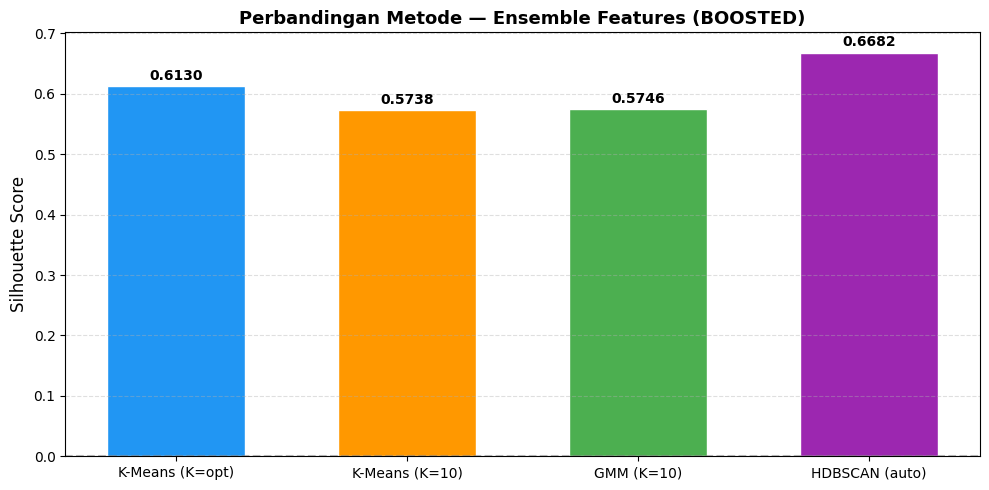


Metode terbaik: HDBSCAN (auto) = 0.6682


In [13]:
methods = [
    ('K-Means (K=opt)', km_scores_opt['sil'], km_scores_opt['dbi'], km_scores_opt['chi'], K_OPTIMAL),
    ('K-Means (K=10)',  km_scores_10['sil'],  km_scores_10['dbi'],  km_scores_10['chi'],  10),
    ('GMM (K=10)',      gmm_scores['sil'],     gmm_scores['dbi'],    gmm_scores['chi'],    10),
]
if HDBSCAN_OK and hdb_scores['sil'] is not None:
    methods.append(('HDBSCAN (auto)', hdb_scores['sil'], hdb_scores['dbi'], None, hdb_scores['n_clusters']))

print(f'{"Metode":<22} {"Silhouette":>12} {"DBI":>8} {"CHI":>10} {"K":>5}')
print('-'*62)
for name, sil, dbi, chi, k in methods:
    chi_s = f'{chi:10.1f}' if chi else '         -'
    print(f'{name:<22} {sil:12.4f} {dbi:8.4f} {chi_s} {k:5d}')

# Bar chart
names_p = [m[0] for m in methods]
sils_p  = [m[1] for m in methods]
colors  = ['#2196F3','#FF9800','#4CAF50','#9C27B0'][:len(methods)]
fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(range(len(methods)), sils_p, color=colors, edgecolor='white', width=0.6)
for bar,v in zip(bars,sils_p):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(methods))); ax.set_xticklabels(names_p, fontsize=10)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Perbandingan Metode — Ensemble Features (BOOSTED)',
             fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.grid(True, axis='y', ls='--', alpha=0.4); plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','04_comparison.png'), dpi=200, bbox_inches='tight'); plt.show()

best_idx = int(np.argmax(sils_p))
BEST_METHOD = names_p[best_idx]; BEST_SIL = sils_p[best_idx]
print(f'\nMetode terbaik: {BEST_METHOD} = {BEST_SIL:.4f}')


## Cell 14 — t-SNE Visualization

t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 593 samples in 0.000s...
[t-SNE] Computed neighbors for 593 samples in 0.022s...
[t-SNE] Computed conditional probabilities for sample 593 / 593
[t-SNE] Mean sigma: 0.019934
[t-SNE] KL divergence after 250 iterations with early exaggeration: 44.199753
[t-SNE] KL divergence after 1000 iterations: 0.104300


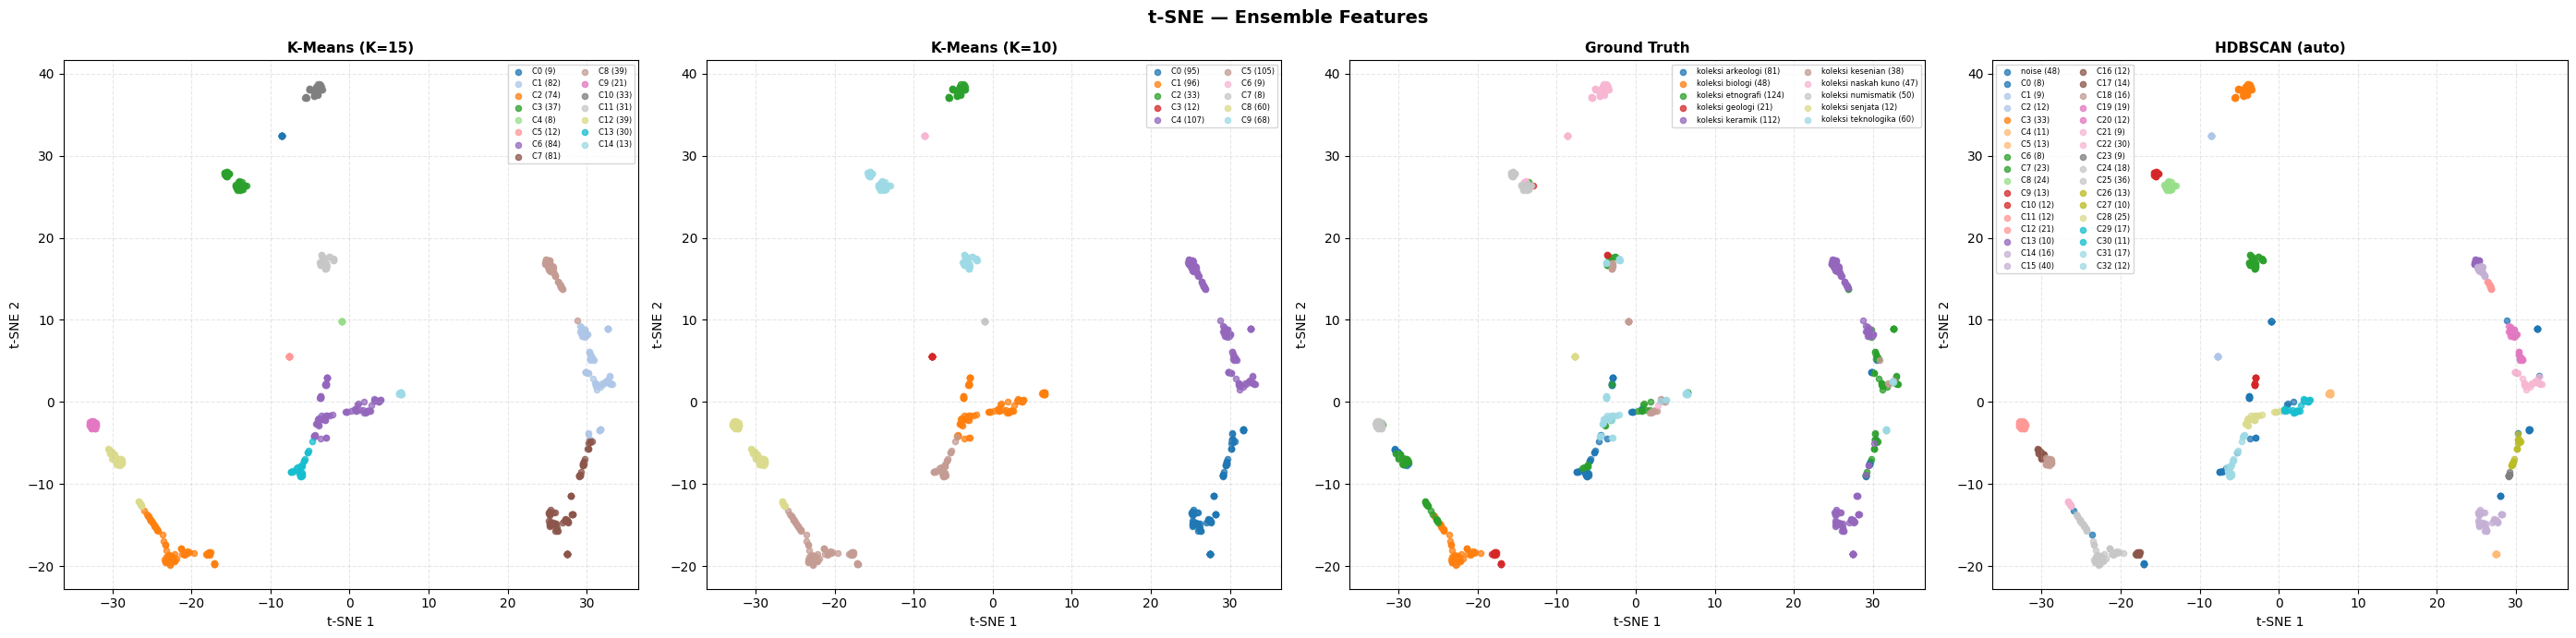

In [14]:
print('t-SNE...')
pca_50 = PCA(n_components=min(50,features_final.shape[1]), random_state=SEED)
tsne_r = TSNE(n_components=2, perplexity=CONFIG['tsne_perplexity'],
              max_iter=1000, random_state=SEED, verbose=1)
feat_tsne = tsne_r.fit_transform(pca_50.fit_transform(features_final))
np.save(os.path.join(CONFIG['output_root'],'tsne_2d.npy'), feat_tsne)

configs_tsne = [
    (km_labels_opt, K_OPTIMAL,        f'K-Means (K={K_OPTIMAL})'),
    (km_labels,     N_CLUSTERS,        'K-Means (K=10)'),
    (gt_labels,     len(class_names), 'Ground Truth'),
]
if HDBSCAN_OK and hdb_labels is not None:
    n_h = len(set(hdb_labels))-(1 if -1 in hdb_labels else 0)
    configs_tsne.append((hdb_labels, n_h+1, 'HDBSCAN (auto)'))

n_panels = len(configs_tsne)
fig, axes = plt.subplots(1, n_panels, figsize=(7*n_panels, 7))
if n_panels == 1: axes = [axes]
for ax, (lbl_t, n_t, title_t) in zip(axes, configs_tsne):
    cmap_fn = plt.cm.get_cmap('tab20', len(set(lbl_t)))
    for i,cl in enumerate(sorted(set(lbl_t))):
        mask = lbl_t==cl
        lbl_s = class_names[cl] if title_t=='Ground Truth' else ('noise' if cl==-1 else f'C{cl}')
        ax.scatter(feat_tsne[mask,0], feat_tsne[mask,1], s=20, alpha=0.75,
                   color=cmap_fn(i), label=f'{lbl_s} ({mask.sum()})')
    ax.set_title(title_t, fontsize=11, fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=6, ncol=2); ax.grid(True, ls='--', alpha=0.3)
plt.suptitle('t-SNE — Ensemble Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','05_tsne.png'), dpi=200, bbox_inches='tight'); plt.show()


## Cell 15 — Silhouette Per-Sampel

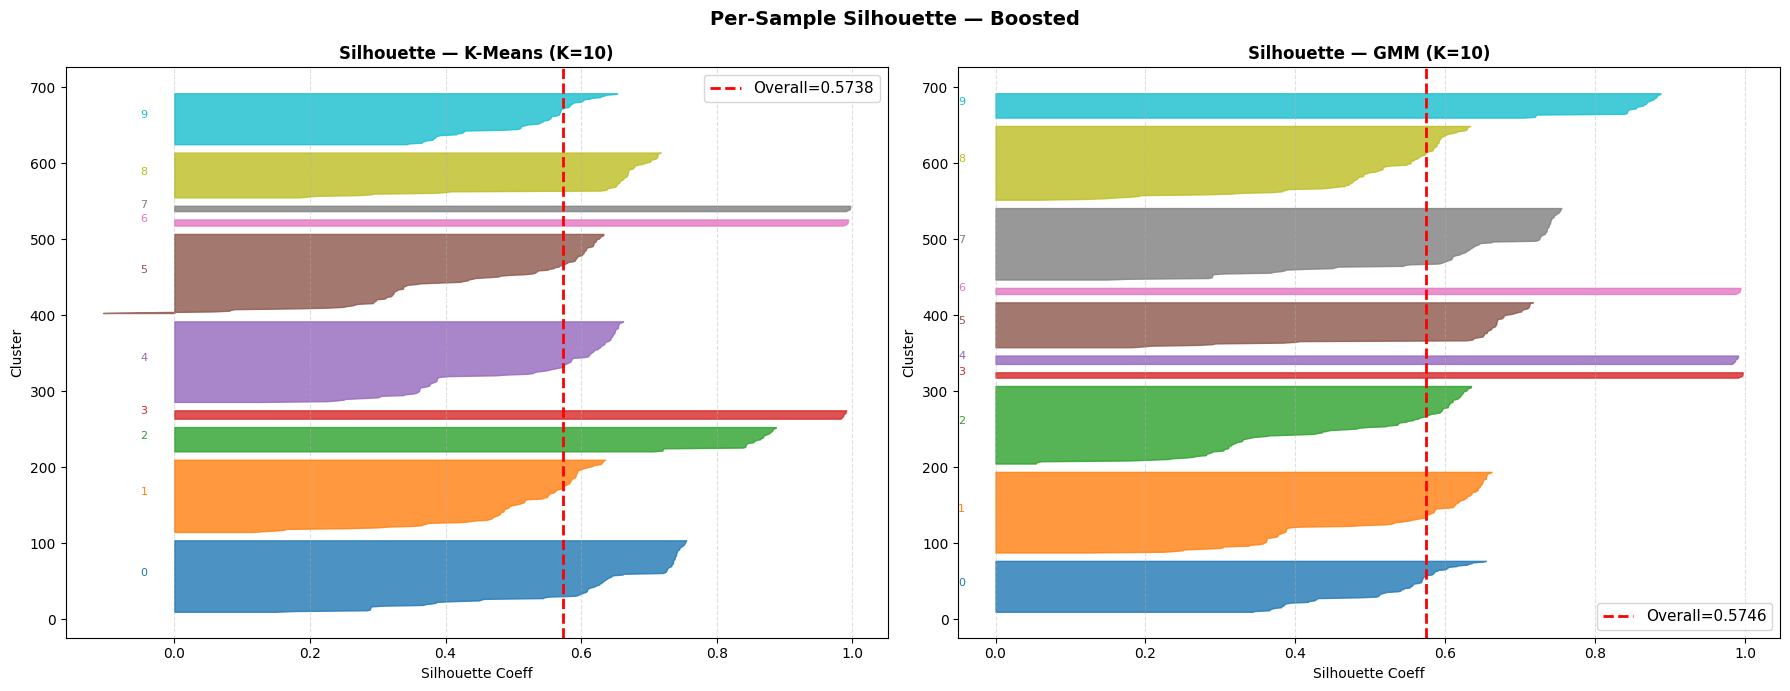

In [15]:
fig, axes = plt.subplots(1,2,figsize=(18,7))
for ax, (lbl_t, title_t, overall) in zip(axes, [
    (km_labels, 'K-Means (K=10)', km_scores_10['sil']),
    (gmm_labels,'GMM (K=10)',     gmm_scores['sil']),
]):
    sil_smp = silhouette_samples(features_final, lbl_t)
    n_cl    = len(np.unique(lbl_t))
    cmap_fn = plt.cm.get_cmap('tab10', n_cl)
    y_lower = 10
    for cl in range(n_cl):
        sil_cl = np.sort(sil_smp[lbl_t==cl])
        sz     = len(sil_cl)
        ax.fill_betweenx(np.arange(y_lower, y_lower+sz), 0, sil_cl,
                         facecolor=cmap_fn(cl), edgecolor=cmap_fn(cl), alpha=0.8)
        ax.text(-0.05, y_lower+0.5*sz, str(cl), fontsize=8, color=cmap_fn(cl))
        y_lower += sz + 10
    ax.axvline(overall, color='red', ls='--', lw=2, label=f'Overall={overall:.4f}')
    ax.set_title(f'Silhouette — {title_t}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Silhouette Coeff'); ax.set_ylabel('Cluster')
    ax.legend(fontsize=11); ax.grid(True, axis='x', ls='--', alpha=0.4)
plt.suptitle('Per-Sample Silhouette — Boosted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','06_silhouette_persample.png'), dpi=200, bbox_inches='tight'); plt.show()


## Cell 16 — Confusion Matrix vs Ground Truth (Hungarian)

Cluster Accuracy (Hungarian):
  K-Means (K=10): 47.72%
  GMM (K=10)    : 47.89%

Mapping K-Means → Kategori:
  C00 → koleksi keramik                (59/95)
  C01 → koleksi teknologika            (40/96)
  C02 → koleksi naskah kuno            (33/33)
  C03 → koleksi senjata                (12/12)
  C04 → koleksi etnografi              (39/107)
  C05 → koleksi biologi                (48/105)
  C06 → koleksi geologi                (0/9)
  C07 → koleksi kesenian               (8/8)
  C08 → koleksi arkeologi              (13/60)
  C09 → koleksi numismatik             (31/68)


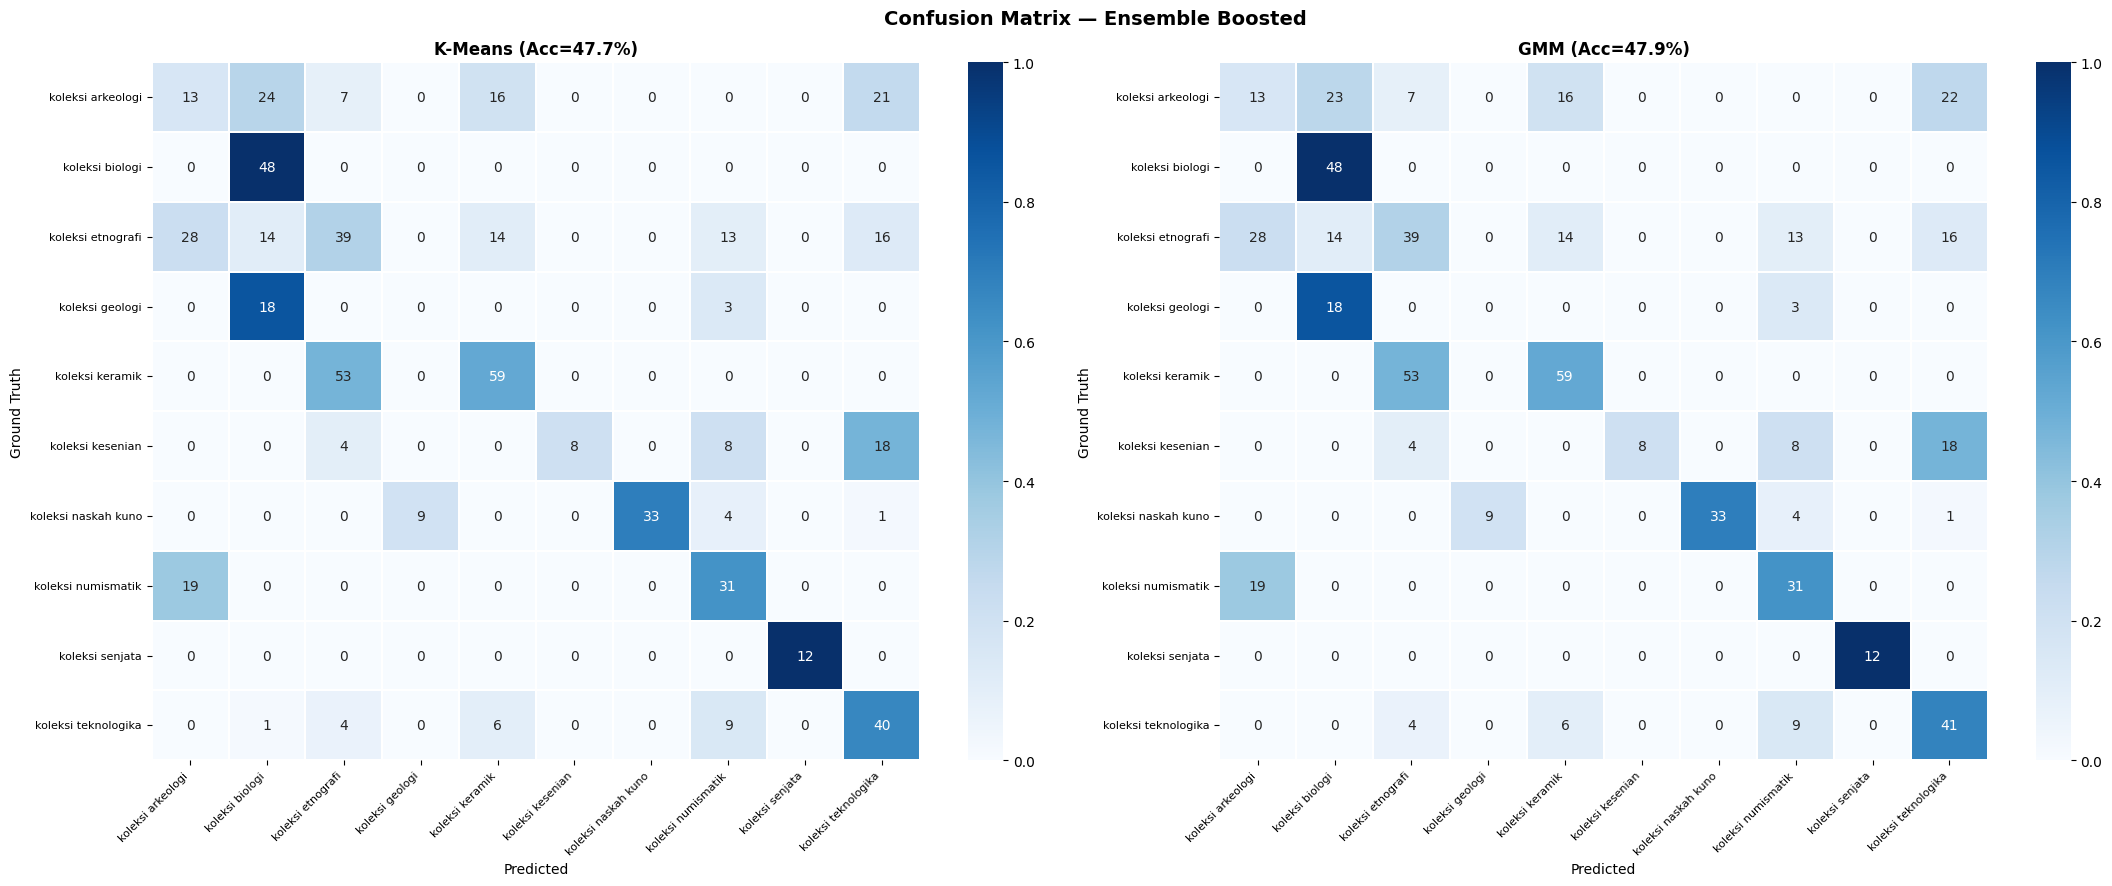

In [16]:
def hungarian_accuracy(gt, pred, class_names):
    unique_pred = sorted(set(pred[pred!=-1]))
    n_p, n_c   = len(unique_pred), len(class_names)
    cost = np.zeros((n_p, n_c), dtype=int)
    for i,cl in enumerate(unique_pred):
        for j in range(n_c): cost[i,j] = np.sum((pred==cl)&(gt==j))
    ri, ci = linear_sum_assignment(-cost)
    mapping = {unique_pred[ri[i]]: ci[i] for i in range(len(ri))}
    pred_m  = np.array([mapping.get(p,-1) for p in pred])
    valid   = pred_m != -1
    acc     = np.sum(pred_m[valid]==gt[valid])/len(gt)
    return acc, mapping, pred_m

acc_km,  map_km,  km_m  = hungarian_accuracy(gt_labels, km_labels,  class_names)
acc_gmm, map_gmm, gmm_m = hungarian_accuracy(gt_labels, gmm_labels, class_names)
print(f'Cluster Accuracy (Hungarian):')
print(f'  K-Means (K=10): {acc_km*100:.2f}%')
print(f'  GMM (K=10)    : {acc_gmm*100:.2f}%')

print('\nMapping K-Means → Kategori:')
for cl,gi in sorted(map_km.items()):
    n_m = np.sum((km_labels==cl)&(gt_labels==gi))
    n_t = np.sum(km_labels==cl)
    print(f'  C{cl:02d} → {class_names[gi]:<30} ({n_m}/{n_t})')

fig, axes = plt.subplots(1,2,figsize=(22,9))
for ax,(pm,title_c) in zip(axes,[
    (km_m,  f'K-Means (Acc={acc_km*100:.1f}%)'),
    (gmm_m, f'GMM (Acc={acc_gmm*100:.1f}%)'),
]):
    valid = pm!=-1
    cm = confusion_matrix(gt_labels[valid], pm[valid], labels=list(range(len(class_names))))
    cm_norm = cm.astype(float)/(cm.sum(axis=1,keepdims=True)+1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.3)
    ax.set_title(title_c, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.suptitle('Confusion Matrix — Ensemble Boosted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','07_confusion.png'), dpi=200, bbox_inches='tight'); plt.show()

km_cluster_names  = {cl:class_names[gi] for cl,gi in map_km.items()}
gmm_cluster_names = {cl:class_names[gi] for cl,gi in map_gmm.items()}


## Cell 17 — Contoh Gambar per Cluster

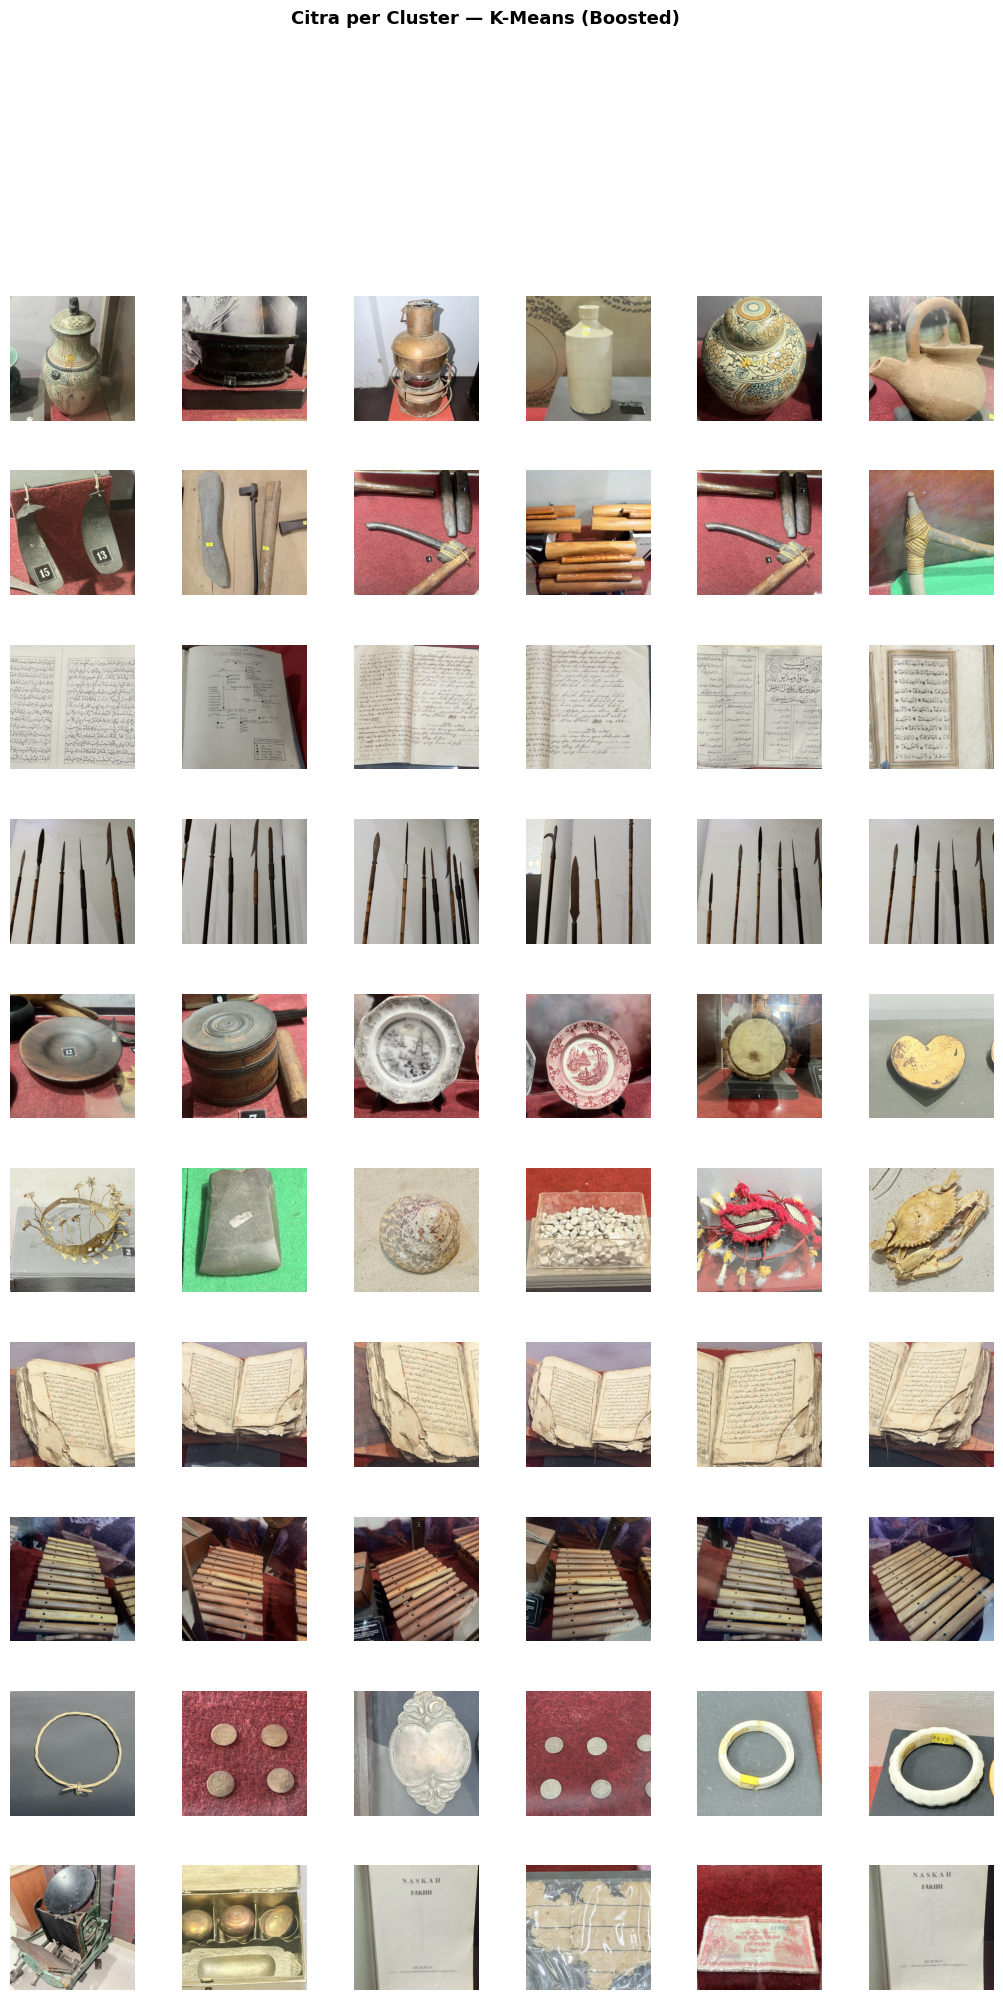

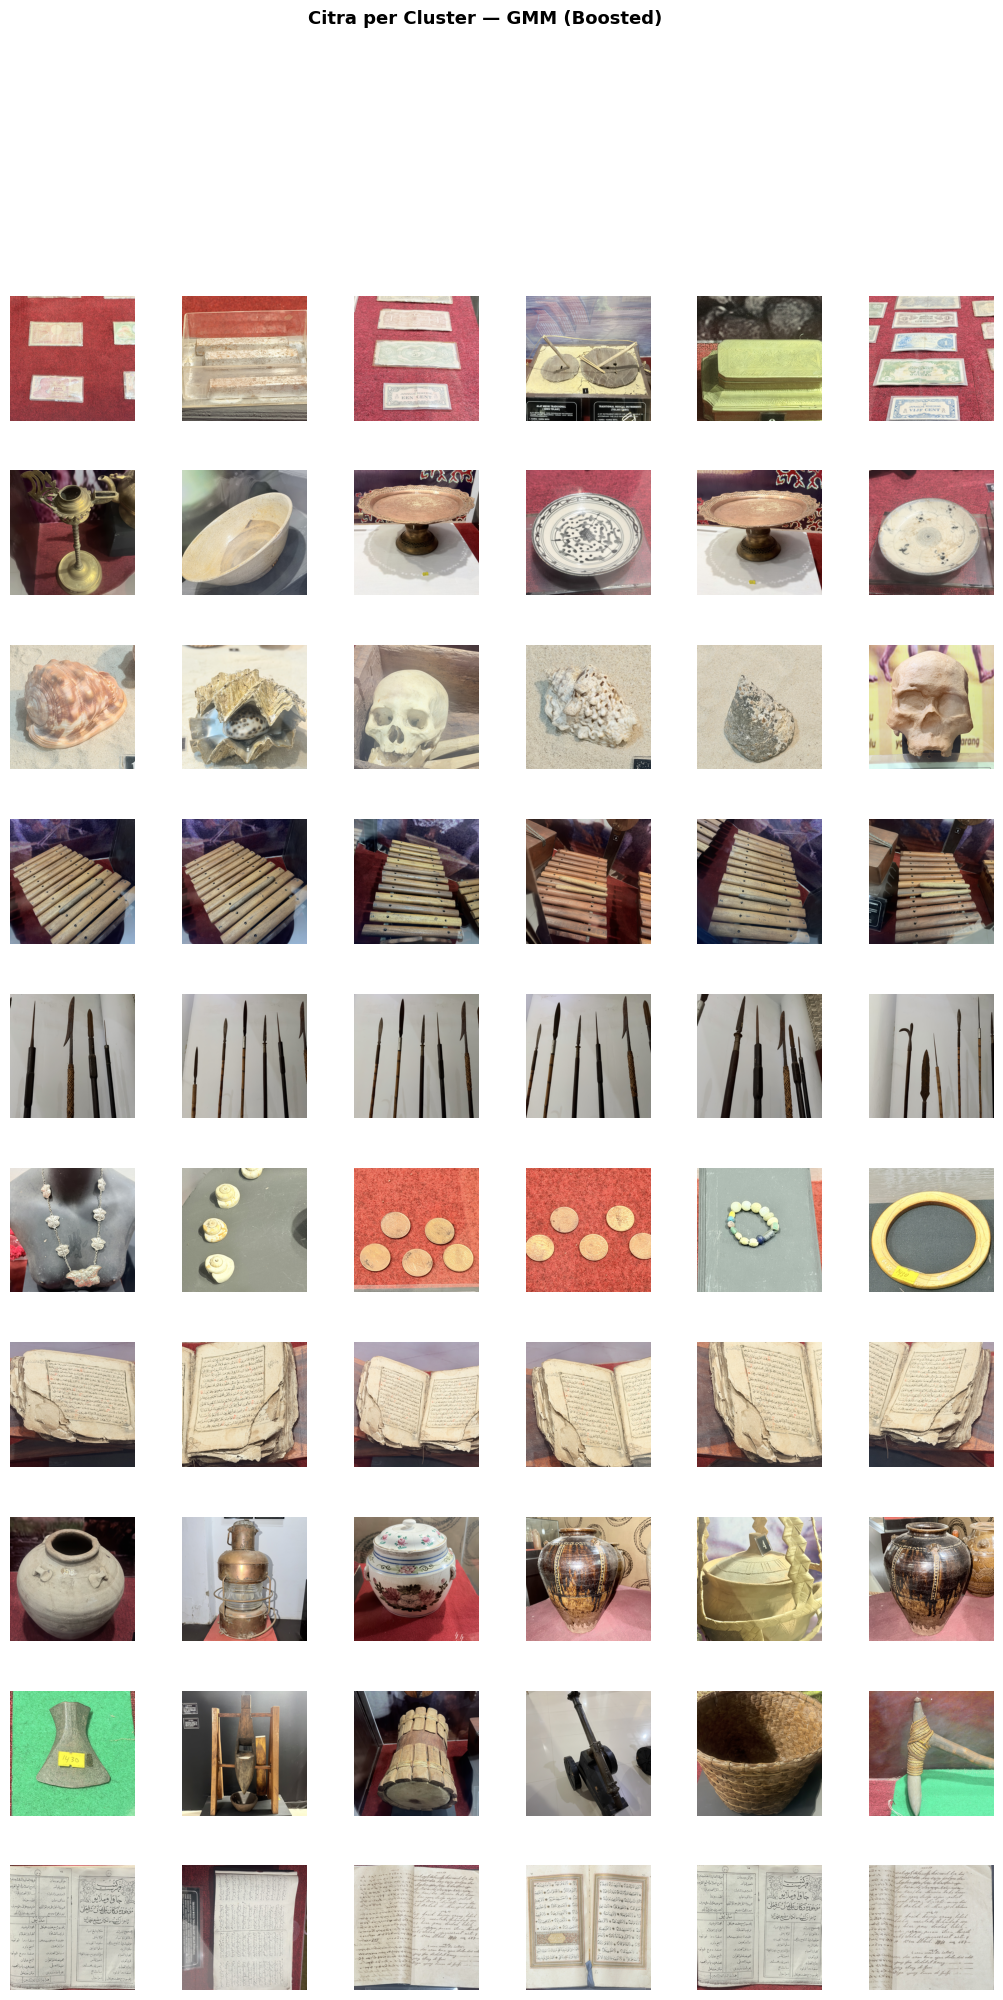

In [17]:
def plot_cluster_samples(images, labels, name_map, n_clusters, n_sample=6, title='', save_path=None):
    valid_cls = [cl for cl in range(n_clusters) if np.any(labels==cl)]
    fig = plt.figure(figsize=(n_sample*2.2, len(valid_cls)*2.2))
    gs  = gridspec.GridSpec(len(valid_cls), n_sample, figure=fig, hspace=0.4, wspace=0.05)
    cmap_fn = plt.cm.get_cmap('tab20', len(valid_cls))
    for ri,cl in enumerate(valid_cls):
        idx_cl = np.where(labels==cl)[0]
        chosen = np.random.choice(idx_cl, min(n_sample,len(idx_cl)), replace=False)
        cat    = name_map.get(cl, f'C{cl}')
        for j,img_idx in enumerate(chosen):
            ax = fig.add_subplot(gs[ri,j])
            img_show = images[img_idx]
            ax.imshow(np.clip(img_show/255.0 if img_show.max()>1 else img_show, 0,1))
            ax.axis('off')
            if j==0:
                ax.set_ylabel(f'C{cl}\n({len(idx_cl)})\n{cat}',
                              fontsize=7, rotation=0, labelpad=60, va='center', color=cmap_fn(ri))
    fig.suptitle(f'Citra per Cluster — {title}', fontsize=13, fontweight='bold', y=1.01)
    if save_path: plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

plot_cluster_samples(images, km_labels,  km_cluster_names,  N_CLUSTERS,
    n_sample=CONFIG['n_sample_vis'], title='K-Means (Boosted)',
    save_path=os.path.join(CONFIG['output_root'],'grafik','08_cluster_kmeans.png'))
plot_cluster_samples(images, gmm_labels, gmm_cluster_names, N_CLUSTERS,
    n_sample=CONFIG['n_sample_vis'], title='GMM (Boosted)',
    save_path=os.path.join(CONFIG['output_root'],'grafik','09_cluster_gmm.png'))


## Cell 18 — Simpan Hasil ke Folder + Manifest CSV

In [18]:
def save_clusters(image_paths, labels, n_clusters, output_dir, method='kmeans', cluster_names=None):
    base_dir = os.path.join(output_dir, f'cluster_{method}')
    for cl in sorted(set(labels)):
        folder = 'noise' if cl==-1 else f'cluster_{cl:02d}__{(cluster_names or {}).get(cl,"?").replace(" ","_")}'
        os.makedirs(os.path.join(base_dir, folder), exist_ok=True)
    manifest = []
    for path,lbl in tqdm(zip(image_paths,labels), total=len(image_paths), desc=f'Save {method}'):
        fname  = os.path.basename(path)
        folder = 'noise' if lbl==-1 else f'cluster_{lbl:02d}__{(cluster_names or {}).get(int(lbl),"?").replace(" ","_")}'
        dest   = os.path.join(base_dir, folder, fname)
        if os.path.exists(dest):
            b,e = os.path.splitext(fname)
            dest = os.path.join(base_dir, folder, f'{b}_{np.random.randint(9999)}{e}')
        shutil.copy2(path, dest)
        manifest.append({'path':path,'cluster':int(lbl),'category':(cluster_names or {}).get(int(lbl),'?') if lbl!=-1 else 'noise',
                          'gt_folder':os.path.basename(os.path.dirname(path)),'dest':dest})
    mpath = os.path.join(output_dir, f'manifest_{method}.csv')
    with open(mpath,'w',newline='',encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=list(manifest[0].keys()))
        w.writeheader(); w.writerows(manifest)
    print(f'[{method}] → {base_dir}')
    return manifest

save_clusters(image_paths, km_labels,  N_CLUSTERS, CONFIG['output_root'], 'kmeans',  km_cluster_names)
save_clusters(image_paths, gmm_labels, N_CLUSTERS, CONFIG['output_root'], 'gmm',     gmm_cluster_names)
if HDBSCAN_OK and hdb_labels is not None:
    n_h = len(set(hdb_labels))-(1 if -1 in hdb_labels else 0)
    save_clusters(image_paths, hdb_labels, n_h, CONFIG['output_root'], 'hdbscan', {})


Save kmeans: 100%|██████████| 593/593 [00:02<00:00, 271.56it/s]


[kmeans] → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_boosted/cluster_kmeans


Save gmm: 100%|██████████| 593/593 [00:01<00:00, 392.99it/s]


[gmm] → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_boosted/cluster_gmm


Save hdbscan: 100%|██████████| 593/593 [00:01<00:00, 353.93it/s]

[hdbscan] → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_boosted/cluster_hdbscan


## Cell 19 — Ringkasan Akhir

In [19]:
print('\n'+'='*72)
print(' RINGKASAN — TRANSFER LEARNING BOOSTED')
print('='*72)
print(f'Dataset          : {len(images)} gambar | {len(class_names)} kategori museum')
print(f'Backbone 1       : EfficientNetV2B2 pretrained (1408D)')
print(f'Backbone 2       : ResNet50V2 pretrained (2048D)')
print(f'Ensemble         : {features_l2.shape[1]}D (L2-concat)')
print(f'Reduksi          : {REDUCTION_METHOD}')
print(f'Final feat dim   : {features_final.shape[1]}D')
print(f'K Optimal        : {K_OPTIMAL}')
print()
print(f'{"Metode":<22} {"Sil(ND)":>10} {"Sil(2D)":>10} {"DBI":>8} {"Acc":>8}')
print('-'*63)
for name, lbl, sil_nd, dbi, acc_v in [
    ('K-Means (K=opt)', km_labels_opt, km_scores_opt['sil'], km_scores_opt['dbi'], None),
    ('K-Means (K=10)',  km_labels,     km_scores_10['sil'],  km_scores_10['dbi'],  acc_km),
    ('GMM (K=10)',      gmm_labels,    gmm_scores['sil'],    gmm_scores['dbi'],    acc_gmm),
]:
    sil_2d_v = sil_2d_results.get(name, {}).get('2d', float('nan')) if UMAP_OK else float('nan')
    acc_s    = f'{acc_v*100:.1f}%' if acc_v is not None else 'N/A'
    print(f'{name:<22} {sil_nd:>10.4f} {sil_2d_v:>10.4f} {dbi:>8.4f} {acc_s:>8}')
if HDBSCAN_OK and hdb_scores['sil']:
    print(f'{"HDBSCAN (auto)":<22} {hdb_scores["sil"]:>10.4f} {"N/A":>10} {hdb_scores["dbi"]:>8.4f} {"N/A":>8}')
print('='*72)
print(f'Metode terbaik: {BEST_METHOD} = {BEST_SIL:.4f}')
print(f'Output dir    : {CONFIG["output_root"]}')
print('='*72)

summary = {
    'backbones': ['EfficientNetV2B2(1408D)', 'ResNet50V2(2048D)'],
    'ensemble_dim': int(features_l2.shape[1]),
    'final_dim': int(features_final.shape[1]),
    'reduction': REDUCTION_METHOD,
    'k_optimal': int(K_OPTIMAL),
    'umap_best_params': best_params_umap,
    'results': {
        'kmeans_opt': {'k': int(K_OPTIMAL), **{k:float(v) for k,v in km_scores_opt.items()}},
        'kmeans_10' : {'k': 10, 'acc': float(acc_km), **{k:float(v) for k,v in km_scores_10.items()}},
        'gmm_10'    : {'k': 10, 'acc': float(acc_gmm), **{k:float(v) for k,v in gmm_scores.items()}},
    },
    'sil_2d': sil_2d_results,
}
with open(os.path.join(CONFIG['output_root'],'ringkasan_final.json'),'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print('Ringkasan tersimpan!')



 RINGKASAN — TRANSFER LEARNING BOOSTED
Dataset          : 593 gambar | 10 kategori museum
Backbone 1       : EfficientNetV2B2 pretrained (1408D)
Backbone 2       : ResNet50V2 pretrained (2048D)
Ensemble         : 3456D (L2-concat)
Reduksi          : PCA128D + UMAP50D {'n_neighbors': 10, 'min_dist': 0.0}
Final feat dim   : 50D
K Optimal        : 15

Metode                    Sil(ND)    Sil(2D)      DBI      Acc
---------------------------------------------------------------
K-Means (K=opt)            0.6130        nan   0.4143      N/A
K-Means (K=10)             0.5738     0.2554   0.4986    47.7%
GMM (K=10)                 0.5746     0.2538   0.4982    47.9%
HDBSCAN (auto)             0.6682        N/A   0.4259      N/A
Metode terbaik: HDBSCAN (auto) = 0.6682
Output dir    : /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_boosted
Ringkasan tersimpan!
